# IBM HR Employee Attrition Analysis

## Objective
The objective of this project is to analyse the IBM HR Employee Attrition dataset, identify the factors influencing employee attrition, preprocess the data, build machine learning models, and evaluate their performance in predicting employee attrition.

## Step 1: Import Required Libraries

The following libraries are imported for data manipulation, visualization, preprocessing, machine learning model building, and evaluation.

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Step 2: Load Dataset

The IBM HR Employee Attrition dataset is loaded into a Pandas DataFrame. The first five rows are displayed to verify successful loading.

In [39]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Step 3: Dataset Overview

This step provides information about the structure of the dataset including rows, columns, data types, and summary statistics.

In [40]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information")
df.info()

print("\nSummary Statistics")
df.describe()

print("\nCategorical Columns")
df.describe(include='object')

Shape of Dataset:
(1470, 35)

Columns:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                      

C:\Users\manik\AppData\Local\Temp\ipykernel_3092\1129838979.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [41]:
print("\nCategorical Columns")
df.describe(include=['object', 'string'])


Categorical Columns


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


## Step 4: Check Missing Values

Checking for missing values is an important preprocessing step. Missing values may affect model performance if not handled properly.

In [42]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Step 5: Check Duplicate Records

Duplicate records may introduce bias into the model. Therefore, duplicates are identified and removed if present.

In [43]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate Rows: 0


## Step 6: Employee Attrition Distribution

The distribution of employees who stayed and left the company is visualized.

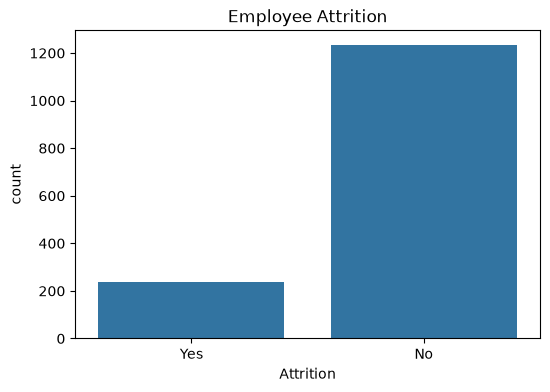

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)

plt.title("Employee Attrition")
plt.show()

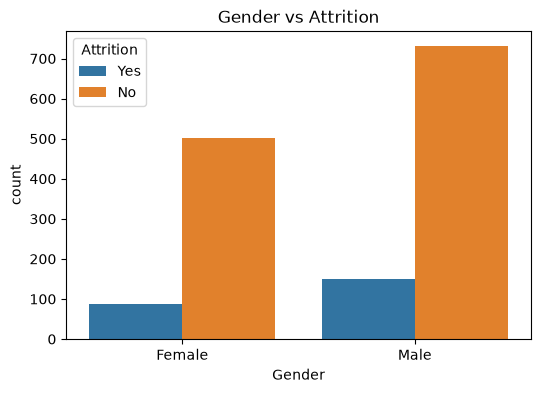

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Attrition', data=df)

plt.title("Gender vs Attrition")
plt.show()

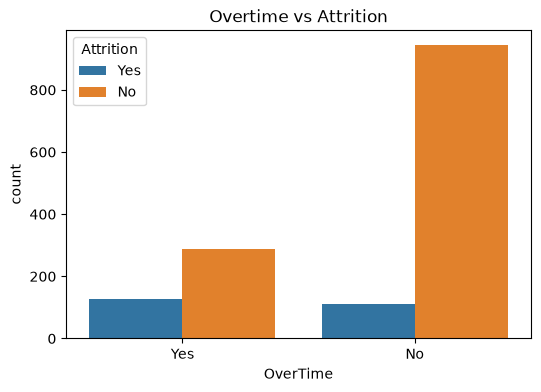

In [46]:
plt.figure(figsize=(6,4))
sns.countplot(x='OverTime', hue='Attrition', data=df)

plt.title("Overtime vs Attrition")
plt.show()

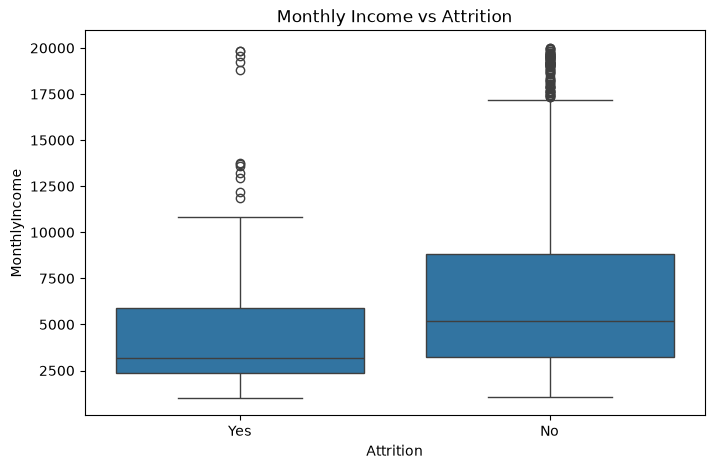

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

plt.title("Monthly Income vs Attrition")
plt.show()

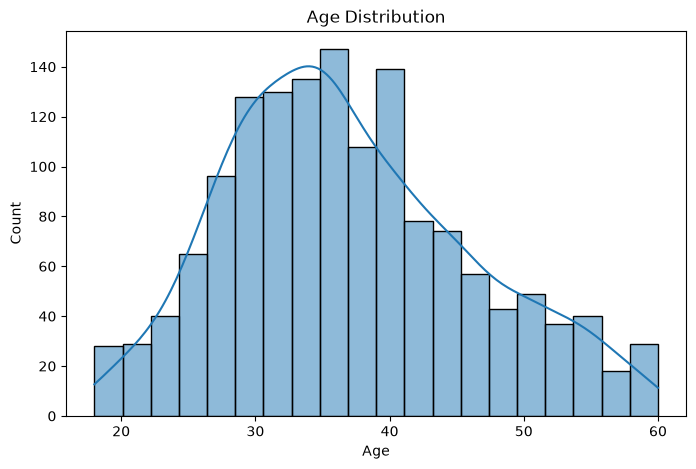

In [48]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()

## Step 7: Correlation Heatmap

A correlation heatmap helps identify relationships among numerical variables.

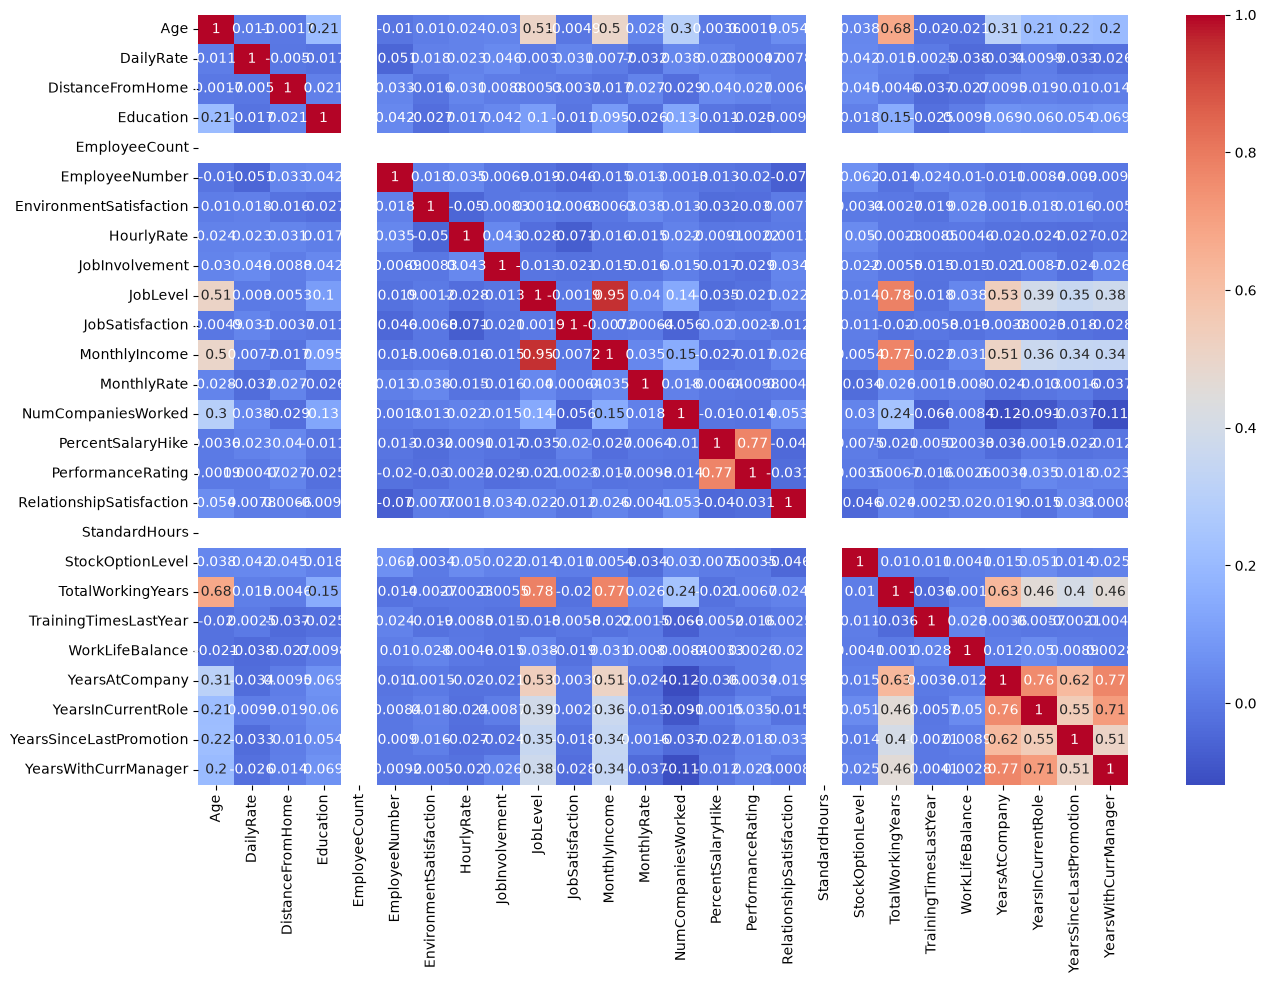

In [49]:
plt.figure(figsize=(15,10))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

## Step 8: Encode Categorical Variables

Machine learning algorithms require numerical input. Therefore, categorical variables are converted into numerical values using Label Encoding.

In [50]:
label = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = label.fit_transform(df[col])

df.head()

C:\Users\manik\AppData\Local\Temp\ipykernel_3092\257193391.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


## Step 9: Select Features and Target Variable

The target variable is Attrition. All remaining columns are used as input features.

In [52]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

## Step 10: Standardize Features

StandardScaler standardizes numerical features so that they have a mean of 0 and a standard deviation of 1.

In [53]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

## Step 11: Split Dataset

The dataset is divided into training and testing sets. The training set is used to train the models, while the testing set is used to evaluate performance.

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Step 12: Logistic Regression

Logistic Regression is a supervised classification algorithm used for binary classification problems.

In [55]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_lr))

print(confusion_matrix(y_test, pred_lr))

print(classification_report(y_test, pred_lr))

Accuracy: 0.891156462585034
[[249   6]
 [ 26  13]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.68      0.33      0.45        39

    accuracy                           0.89       294
   macro avg       0.79      0.65      0.69       294
weighted avg       0.88      0.89      0.87       294



## Step 13: Decision Tree Classifier

Decision Tree learns a set of decision rules from the data and classifies employees accordingly.

In [56]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_dt))

print(confusion_matrix(y_test, pred_dt))

print(classification_report(y_test, pred_dt))

Accuracy: 0.7653061224489796
[[218  37]
 [ 32   7]]
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       255
           1       0.16      0.18      0.17        39

    accuracy                           0.77       294
   macro avg       0.52      0.52      0.52       294
weighted avg       0.78      0.77      0.77       294



## Step 14: Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy.

In [57]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))

print(confusion_matrix(y_test, pred_rf))

print(classification_report(y_test, pred_rf))

Accuracy: 0.8673469387755102
[[251   4]
 [ 35   4]]
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.50      0.10      0.17        39

    accuracy                           0.87       294
   macro avg       0.69      0.54      0.55       294
weighted avg       0.83      0.87      0.83       294



## Step 15: Compare Model Performance

The accuracy scores of all models are compared to identify the best-performing model.

In [58]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.891156
1,Decision Tree,0.765306
2,Random Forest,0.867347


#Accuracy Bar Chart

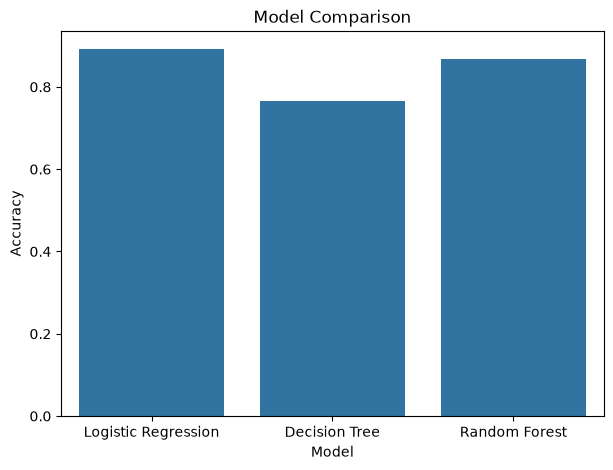

In [59]:
plt.figure(figsize=(7,5))

sns.barplot(x='Model', y='Accuracy', data=results)

plt.title("Model Comparison")

plt.show()

In [60]:
best = results.loc[results['Accuracy'].idxmax()]

print(best)

Model       Logistic Regression
Accuracy               0.891156
Name: 0, dtype: object


# Conclusion

The IBM HR Employee Attrition dataset was successfully analysed using data preprocessing, exploratory data analysis, and machine learning techniques. Logistic Regression, Decision Tree, and Random Forest classifiers were trained and evaluated. Their performances were compared using accuracy, confusion matrices, and classification reports. The best-performing model can assist organizations in identifying employees who are at risk of leaving and enable proactive retention strategies.